In [9]:
import numpy as np
import pandas as pd
import optuna
import warnings
import itertools
import time
import matplotlib.pyplot as plt
import seaborn as sns

# Dataset and Preprocessing
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, KFold, cross_val_predict
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA  # <--- IMPORTIAMO LA PCA
from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.linear_model import RidgeCV
from sklearn.ensemble import StackingRegressor

# Models
from xgboost import XGBRegressor, XGBClassifier
from lightgbm import LGBMRegressor, early_stopping, log_evaluation
from catboost import CatBoostRegressor

# Configuration
optuna.logging.set_verbosity(optuna.logging.WARNING)
warnings.filterwarnings('ignore')

In [10]:
print("1. Data Loading and Cleaning...")

data = fetch_california_housing()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="MedHouseVal")
df = pd.concat([X, y], axis=1)

# Remove the cap at 5.0
df = df[df['MedHouseVal'] < 5.0]

def remove_outliers_iqr(df, columns):
    df_clean = df.copy()
    indices_to_drop = []
    for col in columns:
        Q1 = df_clean[col].quantile(0.3)
        Q3 = df_clean[col].quantile(0.7)
        IQR = Q3 - Q1
        outliers = df_clean[
            (df_clean[col] < Q1 - 2.0 * IQR) |
            (df_clean[col] > Q3 + 2.0 * IQR)
        ].index
        indices_to_drop.extend(outliers)
    return df_clean.drop(list(set(indices_to_drop)))

cols_clean = ['AveRooms', 'AveBedrms', 'AveOccup', 'MedInc']
df = remove_outliers_iqr(df, cols_clean)
print(f"   -> Cleaned dataset: {df.shape}")

1. Data Loading and Cleaning...
   -> Cleaned dataset: (17019, 9)


In [11]:
# ---------------------------------------------------------
# 2. MASSIVE FEATURE ENGINEERING
# ---------------------------------------------------------
print("2. Generating 'Combo' Features...")

def generate_comprehensive_features(df_input, cols_to_combine):
    df_eng = df_input.copy()
    math_cols = [c for c in cols_to_combine if c not in ['Latitude', 'Longitude', 'Geo_Cluster']]
    
    # Coordinate rotation trick
    df_eng['Rot_45_LatLon'] = df_eng['Latitude'] + df_eng['Longitude']
    df_eng['Rot_N45_LatLon'] = df_eng['Latitude'] - df_eng['Longitude']

    # A. LOGARITHMS
    for col in math_cols:
        if df_eng[col].min() >= 0:
            df_eng[f'LOG_{col}'] = np.log1p(df_eng[col])

    # B. MULTIPLICATIONS
    for col1, col2 in itertools.combinations(math_cols, 2):
        col_name = f'MULT_{col1}_x_{col2}'
        df_eng[col_name] = df_eng[col1] * df_eng[col2]

    # C. DIVISIONS / RATIOS
    for col1, col2 in itertools.permutations(math_cols, 2):
        col_name = f'RATIO_{col1}_div_{col2}'
        df_eng[col_name] = df_eng[col1] / (df_eng[col2] + 1e-5)

    return df_eng

# --- Geo Features ---
sf_coords = (37.7749, -122.4194)
la_coords = (34.0522, -118.2437)
df['Dist_SF'] = np.sqrt((df['Latitude'] - sf_coords[0])**2 + (df['Longitude'] - sf_coords[1])**2)
df['Dist_LA'] = np.sqrt((df['Latitude'] - la_coords[0])**2 + (df['Longitude'] - la_coords[1])**2)

coords = df[['Latitude', 'Longitude']]
kmeans = KMeans(n_clusters=15, random_state=42, n_init=10)
df['Geo_Cluster'] = kmeans.fit_predict(StandardScaler().fit_transform(coords))

# Split features and target
X = df.drop('MedHouseVal', axis=1)
y = df['MedHouseVal']

# Generate mathematical features
cols_for_math = [c for c in X.columns if c != 'Geo_Cluster']
X_full = generate_comprehensive_features(X, cols_for_math)

# Clean post-generation
X_full.replace([np.inf, -np.inf], np.nan, inplace=True)
X_full.fillna(0, inplace=True)
print(f"   -> Total Features Generated: {X_full.shape[1]}")

2. Generating 'Combo' Features...
   -> Total Features Generated: 105


3. Applying PCA and Scree Plot...


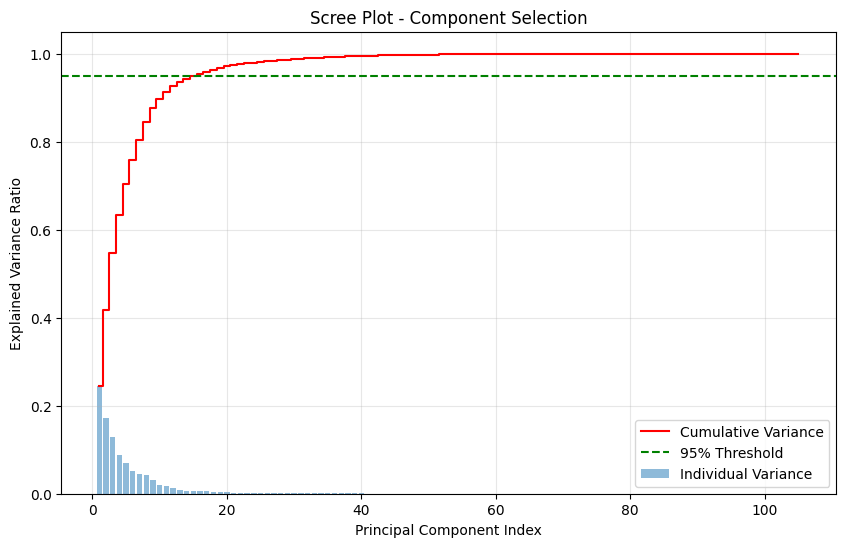

   -> PCA Completed. Features reduced from 105 to 16
   -> Total variance retained: 95.36%


In [12]:
# ---------------------------------------------------------
# 3. DIMENSIONALITY REDUCTION (PCA + SCREE PLOT)
# ---------------------------------------------------------
print("3. Applying PCA and Scree Plot...")

# 3.1 Standardization (REQUIRED for PCA)
# We use StandardScaler because PCA maximizes variance.
# (RobustScaler is fine for outliers, but standardizing to var=1 is standard for PCA)
scaler_pca = StandardScaler()
X_scaled_pca = scaler_pca.fit_transform(X_full)

# 3.2 Fit full PCA for analysis
pca_full = PCA()
pca_full.fit(X_scaled_pca)

# 3.3 Scree Plot
exp_var_pca = pca_full.explained_variance_ratio_
cum_sum_eigenvalues = np.cumsum(exp_var_pca)

plt.figure(figsize=(10, 6))
plt.bar(range(1, len(exp_var_pca) + 1), exp_var_pca, alpha=0.5, label='Individual Variance')
plt.step(range(1, len(cum_sum_eigenvalues) + 1), cum_sum_eigenvalues, where='mid', label='Cumulative Variance', color='red')
plt.axhline(y=0.95, color='green', linestyle='--', label='95% Threshold')
plt.ylabel('Explained Variance Ratio')
plt.xlabel('Principal Component Index')
plt.title('Scree Plot - Component Selection')
plt.legend(loc='best')
plt.grid(True, alpha=0.3)
plt.show()

# 3.4 Automatic Component Selection (95% Variance)
# Instead of using n_components=int, we pass a float between 0 and 1.
# Scikit-learn will automatically select the minimum number of components 
# needed to cover that variance.
pca_final = PCA(n_components=0.95)
X_selected = pca_final.fit_transform(X_scaled_pca)

n_components_kept = X_selected.shape[1]
print(f"   -> PCA Completed. Features reduced from {X_full.shape[1]} to {n_components_kept}")
print(f"   -> Total variance retained: {np.sum(pca_final.explained_variance_ratio_):.2%}")

# Main Split (Train / Test)
# Note: X_selected is now a numpy array, column names are lost but it's fine for models
X_train, X_test, y_train, y_test = train_test_split(X_selected, y, test_size=0.2, random_state=42)

In [13]:
# ---------------------------------------------------------
# 4. OPTUNA WITH PROPER EARLY STOPPING
# ---------------------------------------------------------
print("\n4. Hyperparameter tuning with Optuna and Early Stopping...")

# Create a validation set ONLY for Optuna to monitor early stopping
X_opt_train, X_opt_val, y_opt_train, y_opt_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42
)

N_TRIALS = 50  # Number of trials (increase for better results)

# --- A. XGBoost Optimization ---
def objective_xgb(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 800, 1200),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.5),
        'max_depth': trial.suggest_int('max_depth', 2, 15),
        'subsample': trial.suggest_float('subsample', 0.6, 0.8),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 0.8),
        'alpha': trial.suggest_float('alpha', 1e-7, 15.0, log=True),
        'lambda': trial.suggest_float('lambda', 1e-7, 15.0, log=True),
        'n_jobs': -1, 'random_state': 42
    }
    
    model = XGBRegressor(**params)
    
    # verbose=False suppresses logs, eval_set is used for early stopping
    model.fit(
        X_opt_train, y_opt_train,
        eval_set=[(X_opt_val, y_opt_val)],
        verbose=False
    )
    
    preds = model.predict(X_opt_val)
    return np.sqrt(mean_squared_error(y_opt_val, preds))

print("   -> Optimizing XGBoost...")
study_xgb = optuna.create_study(direction='minimize')
study_xgb.optimize(objective_xgb, n_trials=N_TRIALS)

# --- B. CatBoost Optimization ---
def objective_cat(trial):
    params = {
        'iterations': trial.suggest_int('iterations', 800, 1200),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.5),
        'depth': trial.suggest_int('depth', 1, 10),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1, 10),
        'subsample': trial.suggest_float('subsample', 0.6, 0.8),
        'verbose': 0, 'allow_writing_files': False, 'random_state': 42
    }
    
    model = CatBoostRegressor(**params)
    
    model.fit(
        X_opt_train, y_opt_train,
        eval_set=[(X_opt_val, y_opt_val)],
        early_stopping_rounds=100
    )
    
    preds = model.predict(X_opt_val)
    return np.sqrt(mean_squared_error(y_opt_val, preds))

print("   -> Optimizing CatBoost...")
study_cat = optuna.create_study(direction='minimize')
study_cat.optimize(objective_cat, n_trials=N_TRIALS)

# --- C. LightGBM Optimization (New Callback API) ---
def objective_lgbm(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 800, 1200),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.5),
        'num_leaves': trial.suggest_int('num_leaves', 25, 120),
        'feature_fraction': trial.suggest_float('feature_fraction', 0.6, 0.8),
        'bagging_fraction': trial.suggest_float('bagging_fraction', 0.6, 0.8),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 80),
        'bagging_freq': trial.suggest_int('bagging_freq', 1, 7),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-7, 15.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-7, 15.0, log=True),
        'n_jobs': -1, 'verbose': -1, 'random_state': 42,
    }
    
    model = LGBMRegressor(**params)
    
    # NEW API: use callbacks instead of early_stopping_rounds in .fit()
    callbacks = [
        early_stopping(stopping_rounds=100, verbose=False),
        log_evaluation(period=0)  # Suppress output
    ]
    
    try:
        model.fit(
            X_opt_train, y_opt_train,
            eval_set=[(X_opt_val, y_opt_val)],
            eval_metric='rmse',
            callbacks=callbacks
        )
    except Exception as e:
        # Fallback to CPU if GPU crashes or is not present
        params['device'] = 'cpu'
        model = LGBMRegressor(**params)
        model.fit(
            X_opt_train, y_opt_train,
            eval_set=[(X_opt_val, y_opt_val)],
            eval_metric='rmse',
            callbacks=callbacks
        )

    preds = model.predict(X_opt_val)
    return np.sqrt(mean_squared_error(y_opt_val, preds))

print("   -> Optimizing LightGBM...")
study_lgbm = optuna.create_study(direction='minimize')
study_lgbm.optimize(objective_lgbm, n_trials=N_TRIALS)

# Retrieve best parameters
best_xgb_params = study_xgb.best_params
best_xgb_params.update({'n_estimators': 2000, 'tree_method': 'hist', 'device': 'cpu', 'n_jobs': -1, 'random_state': 42})
# Remove early_stopping_rounds from params for final fit (optional, cleaner)
if 'early_stopping_rounds' in best_xgb_params: del best_xgb_params['early_stopping_rounds']

best_cat_params = study_cat.best_params
best_cat_params.update({'iterations': 2000, 'task_type': 'CPU', 'devices': '0', 'verbose': 0, 'random_state': 42})

best_lgbm_params = study_lgbm.best_params
best_lgbm_params.update({'n_estimators': 2000, 'device': 'cpu', 'n_jobs': -1, 'verbosity': -1, 'random_state': 42})

print("\n--- Optuna Completed. Best parameters found. ---")


4. Hyperparameter tuning with Optuna and Early Stopping...
   -> Optimizing XGBoost...
   -> Optimizing CatBoost...
   -> Optimizing LightGBM...

--- Optuna Completed. Best parameters found. ---


In [14]:
'''
# ---------------------------------------------------------
# 4. OPTUNA WITH EARLY STOPPING
# ---------------------------------------------------------
print("\n4. Hyperparameter tuning with Optuna...")

# Create a validation set for Optuna early stopping
X_opt_train, X_opt_val, y_opt_train, y_opt_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42
)

N_TRIALS = 50  # Slightly reduced for demo brevity

# --- A. XGBoost Optimization ---
def objective_xgb(trial):
    params = {
        'n_estimators': 3000,
        'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.1, log=True),
        'max_depth': trial.suggest_int('max_depth', 4, 10),
        'subsample': trial.suggest_float('subsample', 0.6, 0.95),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 0.95),
        'reg_alpha': trial.suggest_float('reg_alpha', 0.1, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 0.1, 10.0, log=True),
        'tree_method': 'hist',
        'n_jobs': -1,
        'random_state': 42,
        'early_stopping_rounds': 100
    }
    model = XGBRegressor(**params)
    model.fit(X_opt_train, y_opt_train, eval_set=[(X_opt_val, y_opt_val)], verbose=False)
    return np.sqrt(mean_squared_error(y_opt_val, model.predict(X_opt_val)))

print("   -> Optimizing XGBoost...")
study_xgb = optuna.create_study(direction='minimize')
study_xgb.optimize(objective_xgb, n_trials=N_TRIALS)

# --- B. CatBoost Optimization ---
def objective_cat(trial):
    params = {
        'iterations': 3000,
        'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.1, log=True),
        'depth': trial.suggest_int('depth', 6, 12),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1, 10),
        'subsample': trial.suggest_float('subsample', 0.6, 0.95),
        'verbose': 0,
        'allow_writing_files': False,
        'random_state': 42,
        'eval_metric': 'RMSE'
    }
    model = CatBoostRegressor(**params)
    model.fit(X_opt_train, y_opt_train, eval_set=[(X_opt_val, y_opt_val)], early_stopping_rounds=100)
    return np.sqrt(mean_squared_error(y_opt_val, model.predict(X_opt_val)))

print("   -> Optimizing CatBoost...")
study_cat = optuna.create_study(direction='minimize')
study_cat.optimize(objective_cat, n_trials=N_TRIALS)

# --- C. LightGBM Optimization ---
def objective_lgbm(trial):
    params = {
        'n_estimators': 3000,
        'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.1, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 30, 200),
        'feature_fraction': trial.suggest_float('feature_fraction', 0.6, 0.95),
        'bagging_fraction': trial.suggest_float('bagging_fraction', 0.6, 0.95),
        'bagging_freq': trial.suggest_int('bagging_freq', 1, 7),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 100),
        'reg_alpha': trial.suggest_float('reg_alpha', 0.1, 10),
        'reg_lambda': trial.suggest_float('reg_lambda', 0.1, 10),
        'n_jobs': -1,
        'verbosity': -1,
        'random_state': 42,
        'metric': 'rmse'
    }
    model = LGBMRegressor(**params)
    callbacks = [early_stopping(stopping_rounds=100, verbose=False), log_evaluation(period=0)]
    try:
        model.fit(X_opt_train, y_opt_train, eval_set=[(X_opt_val, y_opt_val)], eval_metric='rmse', callbacks=callbacks)
    except:
        params['device'] = 'cpu'
        model = LGBMRegressor(**params)
        model.fit(X_opt_train, y_opt_train, eval_set=[(X_opt_val, y_opt_val)], eval_metric='rmse', callbacks=callbacks)
    return np.sqrt(mean_squared_error(y_opt_val, model.predict(X_opt_val)))

print("   -> Optimizing LightGBM...")
study_lgbm = optuna.create_study(direction='minimize')
study_lgbm.optimize(objective_lgbm, n_trials=N_TRIALS)

# Retrieve best parameters
best_xgb_params = study_xgb.best_params
best_xgb_params.update({'n_estimators': 2000, 'tree_method': 'hist', 'n_jobs': -1, 'random_state': 42})
if 'early_stopping_rounds' in best_xgb_params: del best_xgb_params['early_stopping_rounds']

best_cat_params = study_cat.best_params
best_cat_params.update({'iterations': 2000, 'devices': '0', 'verbose': 0, 'random_state': 42})

best_lgbm_params = study_lgbm.best_params
best_lgbm_params.update({'n_estimators': 2000, 'n_jobs': -1, 'verbosity': -1, 'random_state': 42})
'''

'\n# ---------------------------------------------------------\n# 4. OPTUNA WITH EARLY STOPPING\n# ---------------------------------------------------------\nprint("\n4. Hyperparameter tuning with Optuna...")\n\n# Create a validation set for Optuna early stopping\nX_opt_train, X_opt_val, y_opt_train, y_opt_val = train_test_split(\n    X_train, y_train, test_size=0.2, random_state=42\n)\n\nN_TRIALS = 50  # Slightly reduced for demo brevity\n\n# --- A. XGBoost Optimization ---\ndef objective_xgb(trial):\n    params = {\n        \'n_estimators\': 3000,\n        \'learning_rate\': trial.suggest_float(\'learning_rate\', 0.005, 0.1, log=True),\n        \'max_depth\': trial.suggest_int(\'max_depth\', 4, 10),\n        \'subsample\': trial.suggest_float(\'subsample\', 0.6, 0.95),\n        \'colsample_bytree\': trial.suggest_float(\'colsample_bytree\', 0.6, 0.95),\n        \'reg_alpha\': trial.suggest_float(\'reg_alpha\', 0.1, 10.0, log=True),\n        \'reg_lambda\': trial.suggest_float(\'reg_l

In [15]:
# ---------------------------------------------------------
# 5. SMART SOFT MODEL SELECTOR (MoE)
# ---------------------------------------------------------
print("\n5. Building Smart Soft Selector (MoE)...")

class SmartSoftModelSelector(BaseEstimator, RegressorMixin):
    def __init__(self, estimators, selector_model=None):
        self.estimators = estimators
        # If no selector model is provided, use a default XGBoost classifier
        self.selector_model = selector_model if selector_model else XGBClassifier(
            n_estimators=200, max_depth=6, learning_rate=0.05,
            tree_method='hist', n_jobs=-1, random_state=42
        )
        self.model_names = [name for name, _ in estimators]
        
    def fit(self, X, y):
        self.fitted_estimators_ = []
        # Fit all base models
        for name, model in self.estimators:
            model.fit(X, y)
            self.fitted_estimators_.append(model)
            
        # Generate out-of-fold (OOF) predictions for the selector
        errors = pd.DataFrame()
        for name, model in self.estimators:
            oof_preds = cross_val_predict(model, X, y, cv=5, n_jobs=1)
            errors[name] = np.abs(y - oof_preds)
            
        # Determine which base model is best per sample
        y_best_model_idx = errors.idxmin(axis=1).apply(lambda x: self.model_names.index(x))
        # Fit selector model to predict best model index
        self.selector_model.fit(X, y_best_model_idx)
        return self

    def predict(self, X):
        # Get predictions from all base models
        base_preds = np.column_stack([model.predict(X) for model in self.fitted_estimators_])
        # Get selector probabilities for each model
        weights = self.selector_model.predict_proba(X)
        # Compute weighted sum for final prediction
        final_pred = np.sum(base_preds * weights, axis=1)
        return final_pred

# Define base models with the best-found hyperparameters
estimators_list = [
    ('xgb', XGBRegressor(**best_xgb_params)),
    ('cat', CatBoostRegressor(**best_cat_params)),
    ('lgbm', LGBMRegressor(**best_lgbm_params)) 
]

# Initialize and fit the MoE (Mixture of Experts) model
moe_model = SmartSoftModelSelector(estimators=estimators_list)
moe_model.fit(X_train, y_train)


5. Building Smart Soft Selector (MoE)...


,estimators,"[('xgb', ...), ('cat', ...), ...]"
,selector_model,"XGBClassifier...ree=None, ...)"
,objective,'multi:softprob'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None


In [16]:
# ---------------------------------------------------------
# 6. RESIDUAL LEARNING
# ---------------------------------------------------------
print("\n6. Training Residual Corrector...")

class ResidualCorrectedMoE(BaseEstimator, RegressorMixin):
    def __init__(self, base_moe_model, corrector_model=None):
        self.base_moe_model = base_moe_model
        # Default corrector is a CatBoost regressor
        self.corrector_model = corrector_model if corrector_model else CatBoostRegressor(
            iterations=500, depth=6, learning_rate=0.03, l2_leaf_reg=5, 
            task_type='CPU', devices='0', verbose=0, allow_writing_files=False, random_state=42
        )
        
    def fit(self, X, y):
        # Compute out-of-fold residuals
        oof_preds = cross_val_predict(self.base_moe_model, X, y, cv=5, n_jobs=1)
        residuals = y - oof_preds
        # Fit corrector model on residuals
        self.corrector_model.fit(X, residuals)
        return self

    def predict(self, X):
        # Base prediction from MoE
        base_pred = self.base_moe_model.predict(X)
        # Add residual correction
        correction = self.corrector_model.predict(X)
        return base_pred + correction

# Initialize and fit the full residual-corrected system
final_system = ResidualCorrectedMoE(base_moe_model=moe_model)
final_system.fit(X_train, y_train)

# Evaluation
y_pred_corrected = final_system.predict(X_test)
final_rmse = np.sqrt(mean_squared_error(y_test, y_pred_corrected))
final_r2 = r2_score(y_test, y_pred_corrected)

print(f"\n==========================================")
print(f" FINAL RESULTS (with PCA)")
print(f"==========================================")
print(f" RMSE: {final_rmse:.5f}")
print(f" R^2 : {final_r2:.5f}")
print(f"==========================================")


6. Training Residual Corrector...

 FINAL RESULTS (with PCA)
 RMSE: 0.44462
 R^2 : 0.77283


In [17]:
# ---------------------------------------------------------
# 5. FINAL STACKING (Ensemble)
# ---------------------------------------------------------
print("\n5. Training Final Stacking Ensemble (on full set)...")

# Retrieve the best hyperparameters
best_xgb_params = study_xgb.best_params
# Ensure no residual fit parameters remain
best_xgb_params.update({
    'tree_method': 'hist', 'n_jobs': -1, 
    'random_state': 42, 'early_stopping_rounds': None  # Disable early stopping for final fit
})

best_cat_params = study_cat.best_params
best_cat_params.update({
    'verbose': 0, 
    'allow_writing_files': False, 'random_state': 42
})

best_lgbm_params = study_lgbm.best_params
if study_lgbm.best_params.get('device') == 'cpu':
    best_lgbm_params.update({'n_jobs': -1, 'verbosity': -1, 'random_state': 42})
else:
    best_lgbm_params.update({'n_jobs': -1, 'verbosity': -1, 'random_state': 42})

# Define base models for stacking
estimators = [
    ('xgb', XGBRegressor(**best_xgb_params)),
    ('cat', CatBoostRegressor(**best_cat_params)),
    ('lgbm', LGBMRegressor(**best_lgbm_params))
]

# Note: StackingRegressor does not natively support early stopping for sub-models
# during internal cross-validation, so we use the optimized n_estimators from Optuna
# (Ideally, you should set n_estimators to the optimal values found during tuning,
# but here we leave them high/default for standard stacking.)

stacking = StackingRegressor(
    estimators=estimators,
    final_estimator=RidgeCV(),
    cv=5,
    n_jobs=1
)

# Fit the stacking ensemble on the full training set
stacking.fit(X_train, y_train)


5. Training Final Stacking Ensemble (on full set)...


,estimators,"[('xgb', ...), ('cat', ...), ...]"
,final_estimator,RidgeCV()
,cv,5
,n_jobs,1
,passthrough,False
,verbose,0
,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None


In [18]:
# ---------------------------------------------------------
# 6. FINAL EVALUATION
# ---------------------------------------------------------
# Make predictions on the test set
y_pred = stacking.predict(X_test)

# Compute metrics
final_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
final_r2 = r2_score(y_test, y_pred)

# Print results
print(f"\n==========================================")
print(f" FINAL RESULTS (with PCA)")
print(f"==========================================")
print(f" RMSE: {final_rmse:.5f}")
print(f" R^2 : {final_r2:.5f}")
print(f"==========================================")


 FINAL RESULTS (with PCA)
 RMSE: 0.44360
 R^2 : 0.77387
